### Célula 1 — Setup e Importação de Funções
Configurei o path para acessar o módulo `src/` e importamos as funções de pré-processamento (`clean_text_basic`, `clean_text_full`, `extract_text_features`). Essas funções centralizam toda a lógica de limpeza e feature engineering que será aplicada aos textos.

In [1]:
import sys
sys.path.append('../')  

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from src.text_utils import (
    clean_text_basic, clean_text_full, extract_text_features
)

print("Funções de pré-processamento carregadas!")

Funções de pré-processamento carregadas!


### Célula 2 — Carregamento e Remoção de Duplicatas
Carrega o dataset original e removemos reviews duplicadas para evitar que o modelo memorize exemplos iguais durante o treino. Em seguida, criamos a coluna `label` (1 para positivo, 0 para negativo) e conferimos novamente a distribuição das classes.

In [2]:
# Carregar dados originais
df = pd.read_csv('../data/raw/IMDB Dataset.csv')
print(f"Shape original: {df.shape}")

# Remover duplicatas
n_antes = len(df)
df = df.drop_duplicates(subset=['review']).reset_index(drop=True)
n_depois = len(df)
print(f"Duplicatas removidas: {n_antes - n_depois}")
print(f"Shape após limpeza: {df.shape}")

# Criar label numérica
df['label'] = (df['sentiment'] == 'positive').astype(int)
print(f"\nDistribuição após remoção de duplicatas:")
print(df['label'].value_counts())

Shape original: (50000, 2)
Duplicatas removidas: 418
Shape após limpeza: (49582, 2)

Distribuição após remoção de duplicatas:
label
1    24884
0    24698
Name: count, dtype: int64


### Célula 3 — Aplicação da Limpeza de Texto
Aplicamos a função `clean_text_basic` a todas as reviews, removendo HTML, pontuação, dígitos e normalizando espaços. Medimos o tempo de execução e comparamos visualmente alguns textos antes e depois da limpeza para validar a transformação.

In [3]:
print("Aplicando clean_text_basic...")
start = time.time()
df['review_clean'] = df['review'].apply(clean_text_basic)
elapsed = time.time() - start
print(f"Concluído em {elapsed:.1f} segundos") # como costuma demorar, é bom informar o tempo gasto

# Verificando exemplos
print("\n" + "="*60)
print("EXEMPLOS DE TEXTO ANTES E DEPOIS DA LIMPEZA")
print("="*60)
for i in [0, 5, 100]:
    print(f"\n[Review {i}]")
    print(f"ORIGINAL ({len(df['review'].iloc[i])} chars):")
    print(df['review'].iloc[i][:200])
    print(f"\nLIMPO ({len(df['review_clean'].iloc[i])} chars):")
    print(df['review_clean'].iloc[i][:200])
    print("-"*40)

Aplicando clean_text_basic...
Concluído em 3.2 segundos

EXEMPLOS DE TEXTO ANTES E DEPOIS DA LIMPEZA

[Review 0]
ORIGINAL (1761 chars):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

LIMPO (1079 chars):
one reviewers mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scenes violence set right word trust show faint hearted timid show pulls punches regards
----------------------------------------

[Review 5]
ORIGINAL (656 chars):
Probably my all-time favorite movie, a story of selflessness, sacrifice and dedication to a noble cause, but it's not preachy or boring. It just never gets old, despite my having seen it some 15 or mo

LIMPO (376 chars):
probably time favorite movie story selflessness sacrifice dedication noble cause preachy boring never gets old despite seen times last years paul

### Célula 4 — Extração de Features Numéricas
Utilizamos a função `extract_text_features` para gerar atributos como número de caracteres, palavras, sentenças, exclamações, interrogações, palavras em maiúsculas e proporção de maiúsculas. Analisamos as estatísticas descritivas dessas features e sua correlação com o sentimento positivo.

In [4]:
# Features extras do texto (antes da limpeza)
df = extract_text_features(df)

# Verificação
feat_cols = [c for c in df.columns if c.startswith('feat_')]
print("Features numéricas criadas:")
print(df[feat_cols].describe().round(2))

# Correlação das features com o label
corr = df[feat_cols + ['label']].corr()['label'].drop('label').sort_values(ascending=False)
print("\nCorrelação com sentimento (positivo=1):")
print(corr.round(4))

Features numéricas criadas:
       feat_n_chars  feat_n_words  feat_n_exclamation  feat_n_question  \
count      49582.00      49582.00            49582.00         49582.00   
mean        1310.57        231.35                0.98             0.65   
std          990.76        171.54                2.92             1.53   
min           32.00          4.00                0.00             0.00   
25%          699.00        126.00                0.00             0.00   
50%          971.00        173.00                0.00             0.00   
75%         1592.00        281.00                1.00             1.00   
max        13704.00       2470.00              282.00            45.00   

       feat_n_caps_words  feat_caps_ratio  feat_avg_word_len  
count           49582.00         49582.00           49582.00  
mean                1.57             0.03               4.64  
std                 3.57             0.02               0.34  
min                 0.00             0.00            

### Célula 5 — Verificação da Qualidade Pós-Limpeza
Contamos o número de palavras das reviews já limpas e inspecionamos casos em que o texto ficou com menos de 5 palavras (possíveis outliers ou perda excessiva de conteúdo). Um histograma da distribuição de comprimento pós-limpeza ajuda a definir um corte mínimo para filtrar exemplos degradados.

Reviews com menos de 5 palavras após limpeza: 3

Exemplos problemáticos:
Original: 'This movie is terrible but it has some good effects.'
Limpo: 'movie terrible good effects'

Original: 'Read the book, forget the movie!'
Limpo: 'read book forget movie'

Original: 'What a script, what a story, what a mess!'
Limpo: 'script story mess'



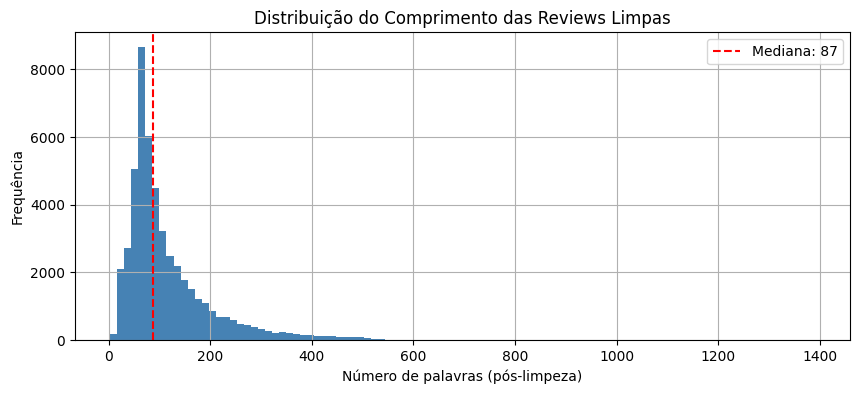

In [5]:
# Verificar reviews que ficaram muito curtas após limpeza
df['clean_word_count'] = df['review_clean'].apply(lambda x: len(x.split()))

# verificando reviews com menos de 5 palavras após limpeza
problematicas = df[df['clean_word_count'] < 5]
print(f"Reviews com menos de 5 palavras após limpeza: {len(problematicas)}")
if len(problematicas) > 0:
    print("\nExemplos problemáticos:")
    for _, row in problematicas.head(5).iterrows():
        print(f"Original: '{row['review'][:100]}'")
        print(f"Limpo: '{row['review_clean']}'")
        print()

# Visualizar distribuição do comprimento das reviews limpas
plt.figure(figsize=(10, 4))
df['clean_word_count'].hist(bins=100, color='steelblue', edgecolor='none')
plt.xlabel('Número de palavras (pós-limpeza)')
plt.ylabel('Frequência')
plt.title('Distribuição do Comprimento das Reviews Limpas')
plt.axvline(df['clean_word_count'].median(), color='red', linestyle='--',
            label=f"Mediana: {df['clean_word_count'].median():.0f}")
plt.legend()
plt.savefig('../reports/figures/06_comprimento_pos_limpeza.png', dpi=150, bbox_inches='tight')
plt.show()

### Célula 6 — Salvamento dos Dados Processados
Selecionamos as colunas relevantes (texto original, texto limpo, sentimento, label e features) e removemos reviews com menos de 3 palavras após a limpeza. Salvamos o DataFrame limpo no formato Parquet (eficiente para disco e leitura) e registramos estatísticas resumidas em um arquivo JSON para consulta futura.

In [6]:
colunas_salvar = ['review', 'review_clean', 'sentiment', 'label'] + feat_cols
df_processed = df[colunas_salvar].copy()

df_processed = df_processed[df_processed['review_clean'].apply(lambda x: len(x.split())) >= 3]
print(f"Shape final após filtros: {df_processed.shape}")

df_processed.to_parquet('../data/processed/imdb_processed.parquet', index=False)
print("Dados processados salvos em data/processed/imdb_processed.parquet")

# Salvar também as estatísticas
stats = {
    'total_reviews': len(df_processed),
    'positive': int(df_processed['label'].sum()),
    'negative': int((df_processed['label'] == 0).sum()),
    'avg_words_clean': float(df_processed['review_clean'].apply(lambda x: len(x.split())).mean()),
}
import json
with open('../data/processed/preprocessing_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)
print("Estatísticas salvas!")

Shape final após filtros: (49582, 11)
Dados processados salvos em data/processed/imdb_processed.parquet
Estatísticas salvas!
